# Step 7-9: ML Model, Churn Probability, Revenue at Risk

Step 4 gave me a rule-based risk score. Now I want to actually build a model and see how it compares. Also want to get a probability per customer instead of just a tier, and use that to get a better revenue at risk number than the dashboard one (which only counts people who already churned).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

sns.set_style('whitegrid')

df = pd.read_csv('telco_churn_segmented.csv')
df.shape

(7043, 26)

In [2]:
df['Churn'].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

about 26.5% churn, matches what I got in step 3. good, no surprises there.

need to drop risk_score, risk_tier, business_segment before modeling - these were built using churn info so they'd leak into the model. value_tier is fine to keep, it's just based on MonthlyCharges buckets, nothing to do with churn.

In [3]:
df['Churn_flag'] = df['Churn'].map({'Yes': 1, 'No': 0})

drop_cols = ['customerID', 'Churn', 'risk_score', 'risk_tier', 'business_segment']
df_model = df.drop(columns=drop_cols)

y = df_model['Churn_flag']
X = df_model.drop(columns=['Churn_flag'])
X = pd.get_dummies(X, drop_first=True)
X.shape

(7043, 36)

In [4]:
X.columns.tolist()

['tenure',
 'MonthlyCharges',
 'TotalCharges',
 'gender_Male',
 'SeniorCitizen_Yes',
 'Partner_Yes',
 'Dependents_Yes',
 'PhoneService_Yes',
 'MultipleLines_No phone service',
 'MultipleLines_Yes',
 'InternetService_Fiber optic',
 'InternetService_No',
 'OnlineSecurity_No internet service',
 'OnlineSecurity_Yes',
 'OnlineBackup_No internet service',
 'OnlineBackup_Yes',
 'DeviceProtection_No internet service',
 'DeviceProtection_Yes',
 'TechSupport_No internet service',
 'TechSupport_Yes',
 'StreamingTV_No internet service',
 'StreamingTV_Yes',
 'StreamingMovies_No internet service',
 'StreamingMovies_Yes',
 'Contract_One year',
 'Contract_Two year',
 'PaperlessBilling_Yes',
 'PaymentMethod_Credit card (automatic)',
 'PaymentMethod_Electronic check',
 'PaymentMethod_Mailed check',
 'tenure_group_13-24 mo',
 'tenure_group_25-48 mo',
 'tenure_group_49-72 mo',
 'tenure_group_7-12 mo',
 'value_tier_Low Value',
 'value_tier_Medium Value']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
y_train.mean(), y_test.mean()

(np.float64(0.2653532126375577), np.float64(0.2654364797728886))

## logistic regression first

going with this as the baseline since it's easy to explain. scaling the features since log reg cares about scale. class_weight balanced because churn is imbalanced and I don't want the model just predicting "no" for everyone.

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_reg.fit(X_train_scaled, y_train)

log_preds = log_reg.predict(X_test_scaled)
log_probs = log_reg.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, log_preds))
print('ROC-AUC:', roc_auc_score(y_test, log_probs))

              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1035
           1       0.51      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409

ROC-AUC: 0.8445865302642797


In [7]:
confusion_matrix(y_test, log_preds)

array([[746, 289],
       [ 76, 298]])

0.84 AUC, not bad. recall on churners is 0.80 which is what I actually care about here - would rather flag someone who wasn't going to leave than miss someone who was.

now trying random forest just to see if it does better.

In [8]:
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)
rf_probs = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, rf_preds))
print('ROC-AUC:', roc_auc_score(y_test, rf_probs))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409

ROC-AUC: 0.824885685499496


hm, accuracy is actually higher (0.79 vs 0.74) but recall on churners dropped to 0.50, worse than log reg's 0.80. so it's "better" overall but worse at the thing I actually care about.

going with logistic regression. catching more actual churners matters more than being slightly more accurate overall - a false alarm costs a retention email, missing a churner costs the customer.

In [9]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.head(10)

TotalCharges                      0.161813
tenure                            0.150833
MonthlyCharges                    0.142362
Contract_Two year                 0.050732
InternetService_Fiber optic       0.043083
PaymentMethod_Electronic check    0.038084
gender_Male                       0.025370
Contract_One year                 0.025282
OnlineSecurity_Yes                0.024737
tenure_group_49-72 mo             0.024422
dtype: float64

top features are TotalCharges, tenure, MonthlyCharges, then Contract_Two year and InternetService_Fiber optic. matches step 3's chi-square results pretty well, good sign.

## step 8 - probability + risk tiers for everyone

can't just run predict_proba on the whole X, because ~80% of rows were in the training set and the model already saw their answer - that's leakage, the probabilities would look better than they really are.

using cross_val_predict instead - trains on 4 folds, predicts the 5th, rotates through, so every row gets a prediction from a model that never saw it.

In [10]:
X_scaled_full = scaler.fit_transform(X)

full_probs = cross_val_predict(
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    X_scaled_full, y, cv=5, method='predict_proba'
)[:, 1]

df['churn_probability'] = full_probs
df['churn_probability'].describe()

count    7043.000000
mean        0.412504
std         0.302240
min         0.006699
25%         0.111864
50%         0.398326
75%         0.693602
max         0.966152
Name: churn_probability, dtype: float64

In [11]:
def assign_risk_tier(prob):
    if prob >= 0.70:
        return 'Critical'
    elif prob >= 0.50:
        return 'High'
    elif prob >= 0.25:
        return 'Medium'
    else:
        return 'Low'

df['ml_risk_tier'] = df['churn_probability'].apply(assign_risk_tier)
df['ml_risk_tier'].value_counts()

ml_risk_tier
Low         2785
Critical    1710
Medium      1359
High        1189
Name: count, dtype: int64

used the same cutoffs as my gut feel from the risk_score tiers, not scientifically picked. might be worth revisiting later but it's fine for now.

checking how this compares to my original business_segment

In [12]:
pd.crosstab(df['business_segment'], df['ml_risk_tier'])

ml_risk_tier,Critical,High,Low,Medium
business_segment,,,,
Critical - At Risk,863,163,0,5
Critical - High Value at Risk,463,6,0,0
High Risk - Low Value,20,208,6,367
High Risk - Monitor Closely,362,655,12,241
Low Risk - Stable,0,0,1867,15
Medium Risk - Watch,2,157,900,731


critical-high value at risk basically all lands in Critical/High which is good. low risk-stable almost all in Low too. the middle ones (watch, monitor closely) are messier and disagree more, but that's kind of expected - the middle is always the hardest to call.

## step 9 - revenue at risk, model version

dashboard version only counts people who already churned (MonthlyCharges * 1 if churned, 0 if not). this version does MonthlyCharges * probability for everyone, so it's an expected value instead of just counting confirmed losses.

In [13]:
df['expected_revenue_at_risk'] = df['MonthlyCharges'] * df['churn_probability']
df['actual_revenue_at_risk'] = np.where(df['Churn'] == 'Yes', df['MonthlyCharges'], 0)

df['actual_revenue_at_risk'].sum(), df['expected_revenue_at_risk'].sum()

(np.float64(139130.84999999998), np.float64(211704.928891909))

$139K rule-based vs $211K model-based. makes sense the model number is higher - it's counting partial risk from people who haven't left yet but are likely to, not just the ones who already did. probably worth putting both numbers in the readme since they're answering slightly different questions.

In [14]:
risk_summary = df.groupby('ml_risk_tier').agg(
    customers=('customerID', 'count'),
    avg_churn_prob=('churn_probability', 'mean'),
    expected_revenue_at_risk=('expected_revenue_at_risk', 'sum')
).sort_values('expected_revenue_at_risk', ascending=False)

risk_summary

,customers,avg_churn_prob,expected_revenue_at_risk
ml_risk_tier,,,
Critical,1710,0.822314,110747.768323
High,1189,0.602151,52247.643054
Medium,1359,0.379148,32248.988014
Low,2785,0.096190,16460.529500


C:\Users\dwara\AppData\Local\Temp\ipykernel_19148\1631201429.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=risk_summary['expected_revenue_at_risk'], y=risk_summary.index, palette='Reds_r', ax=ax)


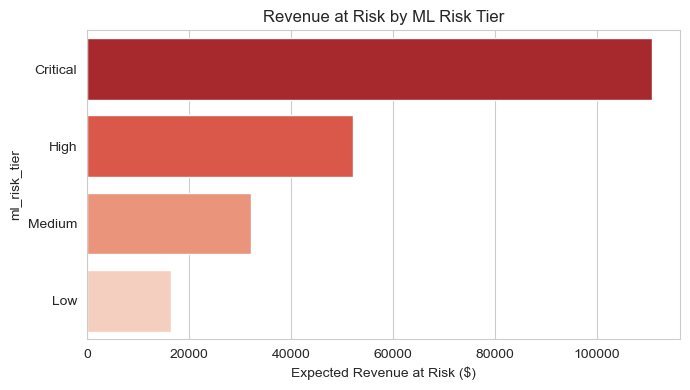

In [15]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=risk_summary['expected_revenue_at_risk'], y=risk_summary.index, palette='Reds_r', ax=ax)
ax.set_xlabel('Expected Revenue at Risk ($)')
ax.set_title('Revenue at Risk by ML Risk Tier')
plt.tight_layout()
plt.show()

saving this, need it later

In [16]:
df.to_csv('telco_churn_with_ml.csv', index=False)
df.shape

(7043, 31)

## summary

- built logistic regression and random forest, went with logistic regression because recall on actual churners was way better (0.80 vs 0.50) even though random forest had higher overall accuracy
- feature importances matched step 3's findings (contract, tenure, internet service, payment method) which was a good sanity check
- used cross_val_predict to avoid leaking training labels into the probability scores
- model-based revenue at risk ($211.7K) is higher than the dashboard's rule-based number ($139.1K) since it accounts for partial risk in customers who haven't churned yet
- rule-based segments and ml tiers mostly agree at the extremes, disagree more in the middle - makes sense, middle segments are just harder to call